In [1]:
%pip install snowflake-sqlalchemy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway


## Connecting to Snowflake

In [3]:
user     = "SHAIK"                  
password = "As1234567890(@)"    
account  = "EI19458"

snowflake_options = {
    "sfURL"       : "EI19458.ap-southeast-7.aws.snowflakecomputing.com",  
    "sfUser"      : "SHAIK",
    "sfPassword"  : "As1234567890(@)",
    "sfDatabase"  : "HR_ANALYSIS",   
    "sfSchema"    : "HR",
    "sfWarehouse" : "COMPUTE_WH"
}


In [5]:
df = (spark.read
      .format("snowflake")
      .options(**snowflake_options)
      .option("dbtable", "employees_info")
      .load())

df.show(5)

In [ ]:
## converting the data inyo pandas dataframe

df=df.toPandas()


In [ ]:
## Copyping The data to Emp 
## Emp for predictive analysis
## df for model building 

emp = df.copy()
emp.columns=emp.columns.str.lower()

## Predictive Analysis

In [ ]:
## checking the datatype
emp.dtypes

employee_id                 object
age                         object
gender                      object
years_at_company            object
job_role                    object
monthly_income              object
work_life_balance           object
job_satisfaction            object
performance_rating          object
number_of_promotions        object
distance_from_home          object
education_level             object
marital_status              object
number_of_dependents        object
job_level                   object
company_size                object
company_tenure              object
company_reputation          object
employee_recognition        object
attrition                   object
overtime                    object
remote_work                 object
leadership_opportunities    object
innovation_opportunities    object
dtype: object

In [ ]:
## Changing the datatype of the columns

emp['age'] = emp['age'].astype('int')
emp['monthly_income'] = emp['monthly_income'].astype('int')
emp['years_at_company'] = emp['years_at_company'].astype('int')
emp['number_of_promotions'] = emp['number_of_promotions'].astype('int')
emp['distance_from_home'] = emp['distance_from_home'].astype('int')
emp['company_tenure'] = emp['company_tenure'].astype('int')
emp['number_of_dependents'] = emp['number_of_dependents'].astype('int')
emp['overtime'] = emp['overtime'].astype('int')
emp['remote_work'] = emp['remote_work'].astype('int')
emp['leadership_opportunities'] = emp['leadership_opportunities'].astype('int')
emp['innovation_opportunities'] = emp['innovation_opportunities'].astype('int')

In [ ]:
emp.dtypes

employee_id                 object
age                          int64
gender                      object
years_at_company             int64
job_role                    object
monthly_income               int64
work_life_balance           object
job_satisfaction            object
performance_rating          object
number_of_promotions         int64
distance_from_home           int64
education_level             object
marital_status              object
number_of_dependents         int64
job_level                   object
company_size                object
company_tenure               int64
company_reputation          object
employee_recognition        object
attrition                   object
overtime                     int64
remote_work                  int64
leadership_opportunities     int64
innovation_opportunities     int64
dtype: object

In [ ]:
## creating the column attrition flage 

emp['attrition_flag'] = emp['attrition'].map({'Stayed':0,'Left':1})

#### Attrition Pressure Index 

In [ ]:
pressure_df = emp.copy()

pressure_df['wlb_score'] = pressure_df['work_life_balance'].map({'Poor':4,'Fair':3,'Good':2,'Excellent':1})
pressure_df['satisfaction_score'] = pressure_df['job_satisfaction'].map({'Low':4,'Medium':3,'High':2,'Very High':1})
pressure_df['overtime_score'] = np.where(pressure_df['overtime']=='Yes',4,1)
pressure_df['pressure_index'] = (pressure_df['wlb_score'] +pressure_df['satisfaction_score'] +pressure_df['overtime_score'] )

pressure_summary = (pressure_df.groupby('attrition')['pressure_index'].mean().reset_index())
pressure_summary

,attrition,pressure_index
0,Left,5.769720
1,Stayed,5.439123


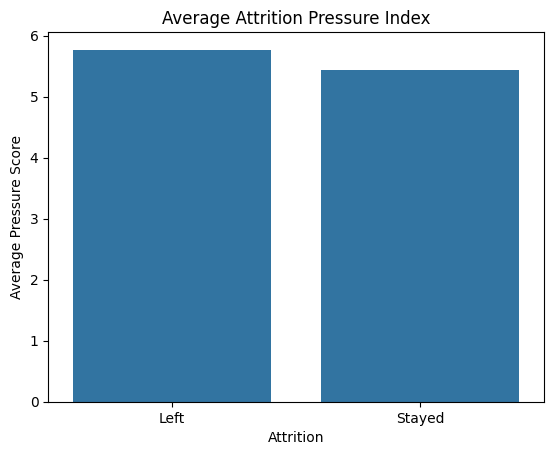

In [ ]:
## ploting the pressure index into bar plot

sns.barplot(data=pressure_summary,x='attrition',y='pressure_index')

plt.title('Average Attrition Pressure Index')
plt.xlabel('Attrition')
plt.ylabel('Average Pressure Score')

plt.show()

### Compensation Inequality Analysis Idea

In [ ]:
emp['expected_income'] = (emp.groupby('years_at_company')['monthly_income'].transform('mean'))

emp['income_gap'] = ( emp['monthly_income'] -emp['expected_income'])

plt.figure(figsize=(12,6))

sns.kdeplot( data=emp, x='income_gap', hue='attrition', fill=True)
plt.title('Income Gap Distribution by Attrition')

plt.show()



### Workforce Fatigue Analysis Idea

In [ ]:
## Create Composite Attrition Risk Index (CARI) 

emp['cari'] = (np.where(emp['overtime'] == 1, 25, 0) +
np.where(emp['work_life_balance'].isin(['Poor', 'Fair']), 25, 0) +
np.where(emp['job_satisfaction'].isin(['Low', 'Medium']), 25, 0)
)

# --- Create Risk Bands ---
emp['risk_tier'] = pd.cut(emp['cari'],bins=[-1, 20, 40, 60, 100],labels=[
        'Low (0–20)',
        'Medium (21–40)',
        'High (41–60)',
        'Critical (61+)'
    ]
)

## Attrition Analysis by Risk Tier ---
risk_analysis = (emp.groupby('risk_tier').agg(headcount=('attrition', 'count'),
        attrited=('attrition', lambda x: (x == 'Left').sum())).reset_index())

#  Calculate Attrition Rate ---
risk_analysis['attrition_rate_pct'] = round(
    (risk_analysis['attrited'] / risk_analysis['headcount']) * 100, 2)

# Sort by Highest Attrition Rate ---
risk_analysis = risk_analysis.sort_values(by='attrition_rate_pct',ascending=False)

(risk_analysis)

        risk_tier  headcount  attrited  attrition_rate_pct
3  Critical (61+)       3228      2052               63.57
2    High (41–60)      18288     10153               55.52
1  Medium (21–40)      33163     15900               47.94
0      Low (0–20)      19819      7265               36.66


/home/spark-c7b689c2-8db4-43e4-97fc-07/.ipykernel/3019/command-8488416752887588-3536310683:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_analysis = (emp.groupby('risk_tier').agg(headcount=('attrition', 'count'),


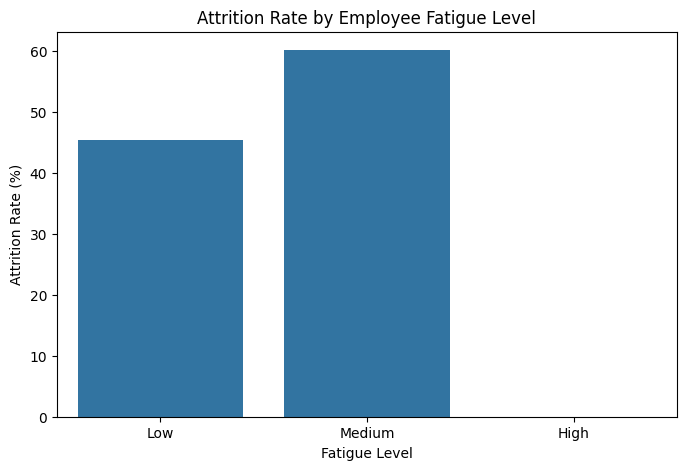

In [ ]:


# Fatigue score
emp['fatigue_score'] = (np.where(emp['overtime'] == 'Yes', 2, 0) +np.where(emp['work_life_balance'] == 'Poor', 2, 0) +
                        np.where(emp['distance_from_home'] > 50, 1, 0))

# Fatigue category
emp['fatigue_category'] = pd.cut(emp['fatigue_score'],bins=[-1, 1, 3, 5],labels=['Low', 'Medium', 'High'],include_lowest=True)

# Convert category to string (important for Databricks plotting)
emp['fatigue_category'] = emp['fatigue_category'].astype(str)

# Create summary table
fatigue_summary = ( emp.groupby('fatigue_category', dropna=False)['attrition_flag'].mean().mul(100).reset_index())

# Plot
plt.figure(figsize=(8,5))

sns.barplot(data=fatigue_summary,x='fatigue_category',y='attrition_flag',order=['Low', 'Medium', 'High'])

plt.ylabel('Attrition Rate (%)')
plt.xlabel('Fatigue Level')
plt.title('Attrition Rate by Employee Fatigue Level')

plt.show()

### Organizational Loyalty Decay Idea

/home/spark-c7b689c2-8db4-43e4-97fc-07/.ipykernel/3019/command-5283265617852129-1462943371:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loyalty = ( emp.groupby('tenure_group')['attrition_flag'] .mean().mul(100).reset_index())


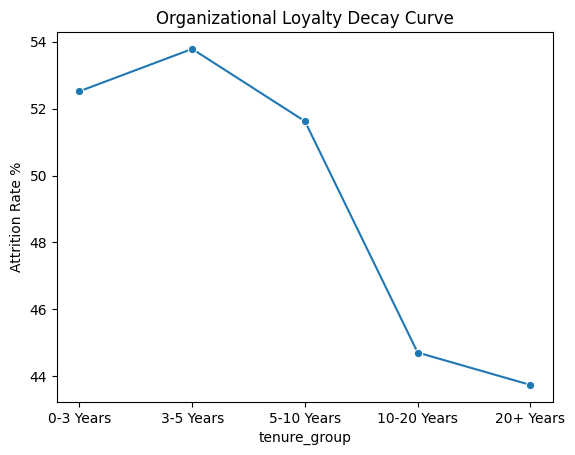

In [ ]:
emp['tenure_group'] = pd.cut(emp['years_at_company'],bins=[0,3,5,10,20,52],labels=[
        '0-3 Years','3-5 Years','5-10 Years','10-20 Years','20+ Years'])


loyalty = ( emp.groupby('tenure_group')['attrition_flag'] .mean().mul(100).reset_index())



sns.lineplot(data=loyalty,x='tenure_group',y='attrition_flag',marker='o')
plt.ylabel('Attrition Rate %')
plt.title('Organizational Loyalty Decay Curve')
plt.show()

## Hypothesis 

### (1) Do employees who leave have significantly different salaries compared to employees who stay?
    
- NUll hypo = There is no significant difference in income between  who stayed and employees who left.
- ALT hypo =There is a significant difference in  income between  who stayed and employees who left.
- significance level = 0.05 
- P-Value = 0.003
### Conclusion
    - SO the p-value < significance level
    - salary has significant relationship with attrition.
    

In [ ]:
stayed_income = emp.loc[emp['attrition']=='Stayed','monthly_income']

left_income = emp.loc[emp['attrition']=='Left','monthly_income']

t_stat, p_value = ttest_ind(stayed_income,left_income)

print('P-Value:', p_value)

P-Value: 0.0035334628636411246


### (2) Does work-life balance differ significantly between employees who stay and leave
    
- NUll hypo = Average work-life balance is same for both groups.
- ALT hypo = Average work-life balance differs between groups.
- P-Value = 0.00
### Conclusion
    - SO the p-value < significance level
    - poor work-life balance contributes to attrition.
        

In [ ]:
wlb_map = {'Poor':1,'Fair':2,'Good':3,'Excellent':4}
emp['wlb_score'] = emp['work_life_balance'].map(wlb_map)


stayed_wlb = emp.loc[emp['attrition']=='Stayed','wlb_score']
left_wlb = emp.loc[ emp['attrition']=='Left', 'wlb_score']

t_stat, p_value = ttest_ind(stayed_wlb,left_wlb)

print('P-Value:', p_value)

P-Value: 0.0


### (3) Is overtime associated with employee attrition?
    
- NUll hypo = Overtime and attrition are independent.
- ALT hypo = Overtime and attrition are associated.
- P-Value =  1.0e-52
### Conclusion
    - SO the p-value < significance level
    - overtime significantly affects attrition.
    

In [ ]:
contingency_table = pd.crosstab(emp['overtime'], emp['attrition'])

chi2, p_value, dof, expected = chi2_contingency( contingency_table)

print('P-Value:', p_value)

P-Value: 1.0053172789509482e-52


### (4) Does attrition risk differ across employee experience levels?

        
- NUll hypo = Attrition risk does not differ across employee experience levels.
- ALT hypo = Attrition risk differs across employee experience levels.
- P-Value =   8.07e-101
### Conclusion
    - SO the p-value < significance level
    - attrition differs across employee career stages.

In [ ]:
emp['career_stage'] = pd.cut(emp['years_at_company'],bins=[0,2,5,10,40],labels=['New','Early','Mid','Senior'])

groups = [group['attrition_flag'].values for name, group in emp.groupby('career_stage')]

f_stat, p_value = f_oneway(*groups)

print('P-Value:', p_value)

P-Value: 8.073268645856391e-101


/home/spark-c7b689c2-8db4-43e4-97fc-07/.ipykernel/3019/command-5595283032805071-2270221215:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group['attrition_flag'].values for name, group in emp.groupby('career_stage')]


## Modeling 

In [ ]:
df

,EMPLOYEE_ID,AGE,GENDER,YEARS_AT_COMPANY,JOB_ROLE,MONTHLY_INCOME,WORK_LIFE_BALANCE,JOB_SATISFACTION,PERFORMANCE_RATING,NUMBER_OF_PROMOTIONS,DISTANCE_FROM_HOME,EDUCATION_LEVEL,MARITAL_STATUS,NUMBER_OF_DEPENDENTS,JOB_LEVEL,COMPANY_SIZE,COMPANY_TENURE,COMPANY_REPUTATION,EMPLOYEE_RECOGNITION,ATTRITION,OVERTIME,REMOTE_WORK,LEADERSHIP_OPPORTUNITIES,INNOVATION_OPPORTUNITIES
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,22,Associate Degree,Married,0,Mid,Medium,89,Excellent,Medium,Stayed,0,0,0,0
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,21,Master’s Degree,Divorced,3,Mid,Medium,21,Fair,Low,Stayed,0,0,0,0
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,11,Bachelor’s Degree,Married,3,Mid,Medium,74,Poor,Low,Stayed,0,0,0,0
3,65791,36,Female,7,Education,3989,Good,High,High,1,27,High School,Single,2,Mid,Small,50,Good,Medium,Stayed,0,1,0,0
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,71,High School,Divorced,0,Senior,Medium,68,Fair,Medium,Stayed,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74493,16243,56,Female,42,Healthcare,7830,Poor,Medium,Average,0,40,Associate Degree,Single,0,Senior,Medium,60,Poor,Medium,Stayed,1,0,0,0
74494,47175,30,Female,15,Education,3856,Good,Medium,Average,2,45,Master’s Degree,Married,0,Entry,Medium,20,Good,Medium,Left,1,0,0,0
74495,12409,52,Male,5,Education,5654,Good,Very High,Below Average,0,4,Associate Degree,Married,4,Mid,Small,7,Good,High,Left,0,0,0,0
74496,9554,18,Male,4,Education,5276,Fair,High,Average,0,13,Bachelor’s Degree,Divorced,3,Mid,Large,5,Poor,High,Stayed,0,0,0,0


In [ ]:
df.dtypes

EMPLOYEE_ID                 object
AGE                         object
GENDER                      object
YEARS_AT_COMPANY            object
JOB_ROLE                    object
MONTHLY_INCOME              object
WORK_LIFE_BALANCE           object
JOB_SATISFACTION            object
PERFORMANCE_RATING          object
NUMBER_OF_PROMOTIONS        object
DISTANCE_FROM_HOME          object
EDUCATION_LEVEL             object
MARITAL_STATUS              object
NUMBER_OF_DEPENDENTS        object
JOB_LEVEL                   object
COMPANY_SIZE                object
COMPANY_TENURE              object
COMPANY_REPUTATION          object
EMPLOYEE_RECOGNITION        object
ATTRITION                   object
OVERTIME                    object
REMOTE_WORK                 object
LEADERSHIP_OPPORTUNITIES    object
INNOVATION_OPPORTUNITIES    object
dtype: object

In [ ]:
## making the the all columns name into lower case for convenience

df.columns=df.columns.str.lower()

In [ ]:
## chaging the column data types from object to int 

df['age'] = df['age'].astype('int')
df['monthly_income'] = df['monthly_income'].astype('int')
df['years_at_company'] = df['years_at_company'].astype('int')
df['number_of_promotions'] = df['number_of_promotions'].astype('int')
df['distance_from_home'] = df['distance_from_home'].astype('int')
df['company_tenure'] = df['company_tenure'].astype('int')
df['number_of_dependents'] = df['number_of_dependents'].astype('int')
df['overtime'] = df['overtime'].astype('int')
df['remote_work'] = df['remote_work'].astype('int')
df['leadership_opportunities'] = df['leadership_opportunities'].astype('int')
df['innovation_opportunities'] = df['innovation_opportunities'].astype('int')

In [ ]:
df.dtypes

employee_id                 object
age                          int64
gender                      object
years_at_company             int64
job_role                    object
monthly_income               int64
work_life_balance           object
job_satisfaction            object
performance_rating          object
number_of_promotions         int64
distance_from_home           int64
education_level             object
marital_status              object
number_of_dependents         int64
job_level                   object
company_size                object
company_tenure               int64
company_reputation          object
employee_recognition        object
attrition                   object
overtime                     int64
remote_work                  int64
leadership_opportunities     int64
innovation_opportunities     int64
dtype: object

In [ ]:
##describing the numerci columns

df.select_dtypes(exclude = ['object']).describe()

,age,years_at_company,monthly_income,number_of_promotions,distance_from_home,number_of_dependents,company_tenure,overtime,remote_work,leadership_opportunities,innovation_opportunities
count,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000,74498.000000
mean,38.529746,15.721603,7299.379514,0.832935,49.991584,1.650326,55.727456,0.326734,0.190582,0.049035,0.162474
std,12.083456,11.223744,2152.508566,0.995289,28.513611,1.553633,25.399349,0.469022,0.392763,0.215942,0.368888
min,18.000000,1.000000,1226.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,7.000000,5652.000000,0.000000,25.000000,0.000000,36.000000,0.000000,0.000000,0.000000,0.000000
50%,39.000000,13.000000,7348.000000,1.000000,50.000000,1.000000,56.000000,0.000000,0.000000,0.000000,0.000000
75%,49.000000,23.000000,8876.000000,2.000000,75.000000,3.000000,76.000000,1.000000,0.000000,0.000000,0.000000
max,59.000000,51.000000,16149.000000,4.000000,99.000000,6.000000,128.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
## No NAN founded

df.isna().sum().sum()

np.int64(0)

In [ ]:
## NO duplicate records

df.duplicated().sum().sum()

np.int64(0)

In [ ]:
## deleting the id variable 
del df['employee_id']

### Checking Outliers

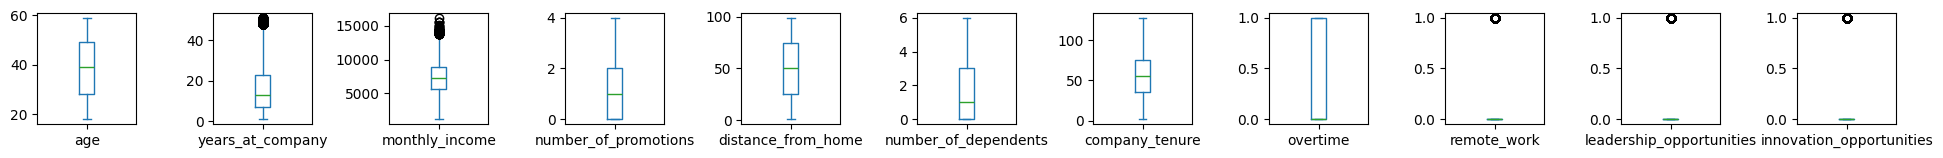

In [ ]:
## ploting all the numerical columns into box plot for outliers checking 

df.select_dtypes(exclude='object').plot(kind='box', subplots=True, layout=(20,20), figsize=(35,30))
plt.tight_layout()
plt.show()

### splitting the data for data preparation 

In [ ]:
# splitting the data to numerical and categorical variables
## some variables  are in numeric data type but they are not numeric 

# numerical variables

num_var = df[df.select_dtypes(exclude='object').columns.difference(['remote_work', 'overtime','leadership_opportunities','innovation_opportunities'])]


non_out_perf_num_var = num_var[num_var.columns.difference(['years_at_company','monthly_income'])]


out_perf_num_var = num_var[['years_at_company','monthly_income']]



# categorical variables

cat_var = df[df.select_dtypes(include='object').columns.to_list() + ['remote_work', 'overtime','leadership_opportunities','innovation_opportunities']]
cat_var = cat_var[cat_var.columns.difference(['attrition'])]


od_cat_var = cat_var[['work_life_balance', 'job_satisfaction','performance_rating', 'education_level', 'job_level' ,'company_reputation', 'employee_recognition']]


nom_cat_var = cat_var[['gender', 'marital_status', 'job_role','company_size']]


non_enc_cat_var = cat_var[['overtime','remote_work','leadership_opportunities','innovation_opportunities']]


# Y variables

y_var = df['attrition']

## performing Outlier treatment 


In [ ]:
## lower cap will be 1st percentail of the column
## upper cap will be 99th percentail of the column

for col in out_perf_num_var:
    lower_bound = out_perf_num_var[col].quantile(0.01)
    upper_bound = out_perf_num_var[col].quantile(0.99)
    out_perf_num_var[col] = num_var[col].clip(lower=lower_bound, upper=upper_bound)

/home/spark-c7b689c2-8db4-43e4-97fc-07/.ipykernel/3019/command-4728814327343256-1746380303:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  out_perf_num_var[col] = num_var[col].clip(lower=lower_bound, upper=upper_bound)
/home/spark-c7b689c2-8db4-43e4-97fc-07/.ipykernel/3019/command-4728814327343256-1746380303:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  out_perf_num_var[col] = num_var[col].clip(lower=lower_bound, upper=upper_bound)


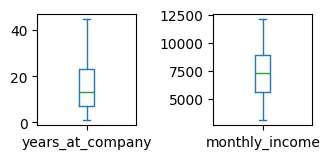

In [ ]:

out_perf_num_var.select_dtypes(exclude='object').plot(kind='box', subplots=True, layout=(20,20), figsize=(35,30))
plt.tight_layout()
plt.show()

In [ ]:
clean_num_var = pd.concat([out_perf_num_var,non_out_perf_num_var],axis=1) 

### Encoding 

In [ ]:
performance_rating_map = {"Below Average" : 0,"Low" : 1,"Average" : 2,"High" : 3}

job_level_map = {"Entry": 0,"Mid": 1,"Senior" : 2}

company_reputation_map = {"Poor": 0,"Fair" : 1,"Good": 2,"Excellent" : 3}

employee_recognition_map = {"Low": 0,"Medium": 1,"High" : 2,"Very High" : 3}
job_satisfaction_map = {"Low": 0,"Medium": 1,"High" : 2,"Very High" : 3}

work_life_balance_map = {"Poor" : 0,"Fair" : 1,"Good" : 2,"Excellent" : 3
}
education_level_map = {"High School" : 0, "Associate Degree"  : 1, "Bachelor’s Degree" : 2, "Master’s Degree" : 3, "PhD" : 4
}

od_cat_var["education_level"] = od_cat_var["education_level"].map(education_level_map)
od_cat_var["work_life_balance"]   = od_cat_var["work_life_balance"].map(work_life_balance_map)
od_cat_var["job_satisfaction"]    = od_cat_var["job_satisfaction"].map(job_satisfaction_map)
od_cat_var["performance_rating"]  = od_cat_var["performance_rating"].map(performance_rating_map)
od_cat_var["job_level"]           = od_cat_var["job_level"].map(job_level_map)
od_cat_var["company_reputation"]  = od_cat_var["company_reputation"].map(company_reputation_map)
od_cat_var["employee_recognition"]= od_cat_var["employee_recognition"].map(employee_recognition_map)

/home/spark-c7b689c2-8db4-43e4-97fc-07/.ipykernel/3019/command-7393980854631908-2438353280:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  od_cat_var["education_level"] = od_cat_var["education_level"].map(education_level_map)
/home/spark-c7b689c2-8db4-43e4-97fc-07/.ipykernel/3019/command-7393980854631908-2438353280:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  od_cat_var["work_life_balance"]   = od_cat_var["work_life_balance"].map(work_life_balance_map)
/home/spark-c7b689c2-8db4-43e4-97fc-07/.ipykerne

In [ ]:
nom_cat_var = pd.get_dummies(nom_cat_var, drop_first=True).astype('int')

In [ ]:
clean_cat_avr = pd.concat([od_cat_var,nom_cat_var,non_enc_cat_var],axis=1)

In [ ]:
y_var = (y_var == 'Left').astype('int')

In [ ]:
clean_df = pd.concat([clean_num_var,clean_cat_avr],axis=1)


### Feature Selection

In [ ]:
from sklearn.feature_selection import SelectKBest,f_classif

In [ ]:
x=clean_df
y=y_var

selector=SelectKBest(score_func=f_classif,k='all')
selector.fit(x,y)

f_scores =  pd.DataFrame({'Variable': x.columns,'F_score': selector.scores_,'p_value': selector.pvalues_}) 

f_scores = (f_scores.sort_values(by='F_score', ascending=False))

kbest_imp_var = f_scores.head(10)['Variable'].tolist()
kbest_imp_var

['job_level',
 'marital_status_Single',
 'marital_status_Married',
 'remote_work',
 'work_life_balance',
 'company_reputation',
 'gender_Male',
 'distance_from_home',
 'number_of_promotions',
 'number_of_dependents']

### Anova

In [ ]:

from sklearn.feature_selection import f_classif

X = clean_df
y = y_var

f_values, p_values = f_classif(X, y)

anova_df = pd.DataFrame({'Feature': X.columns,'p_value': p_values,'F_value': f_values}).sort_values(by='F_value', ascending=False)

anova_imp_var = anova_df.head(10)['Feature'].to_list()
anova_imp_var

['job_level',
 'marital_status_Single',
 'marital_status_Married',
 'remote_work',
 'work_life_balance',
 'company_reputation',
 'gender_Male',
 'distance_from_home',
 'number_of_promotions',
 'number_of_dependents']

## RFE

In [ ]:

from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)

rfe = RFE(model, n_features_to_select=10)
rfe.fit(X,y)

important_rfe = X.columns[rfe.support_]
important_rfe=important_rfe.to_list()
important_rfe

/databricks/python/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/databricks/python/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

['number_of_promotions',
 'work_life_balance',
 'job_level',
 'company_reputation',
 'gender_Male',
 'marital_status_Married',
 'marital_status_Single',
 'company_size_Small',
 'overtime',
 'remote_work']

In [ ]:
important_rfe

['number_of_promotions',
 'work_life_balance',
 'job_level',
 'company_reputation',
 'gender_Male',
 'marital_status_Married',
 'marital_status_Single',
 'company_size_Small',
 'overtime',
 'remote_work']

In [ ]:
## selecting the unique feature from the 3 feature reduction methods

imp_var= pd.concat([pd.Series(kbest_imp_var),pd.Series(important_rfe),pd.Series(anova_imp_var)]).unique()

## VIF 

In [8]:
## VIF 
%pip install statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


X = clean_df[imp_var].copy()

while True:
    X_const = add_constant(X)
    
    vif = pd.DataFrame()
    vif["Feature"] = X_const.columns
    vif["VIF"] = [variance_inflation_factor(X_const.values, i) 
                  for i in range(X_const.shape[1])]
    
    vif = vif[vif["Feature"] != "const"]
    
    max_vif = vif["VIF"].max()
    
    if max_vif > 5:
        drop_feature = vif.sort_values("VIF", ascending=False)["Feature"].iloc[0]
        print(f"Removing: {drop_feature} (VIF={max_vif})")
        X = X.drop(columns=[drop_feature])
    else:
        break

print("Final Features:", X.columns)

In [ ]:
final_df = clean_df[X.columns]
final_df['attrition'] = y_var
final_df

In [ ]:
 final_df['job_satisfaction'] = clean_cat_avr['job_satisfaction']

/home/spark-c7b689c2-8db4-43e4-97fc-07/.ipykernel/3019/command-4744777339998403-4226696789:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['job_satisfaction'] = clean_cat_avr['job_satisfaction']


In [ ]:
final_df

,job_level,marital_status_Single,marital_status_Married,remote_work,work_life_balance,company_reputation,gender_Male,distance_from_home,number_of_promotions,number_of_dependents,company_size_Small,overtime,attrition,job_satisfaction
0,1,0,1,0,3,3,1,22,2,0,0,0,0,1
1,1,0,0,0,0,1,0,21,3,3,0,0,0,2
2,1,0,1,0,2,0,0,11,0,3,0,0,0,2
3,1,1,0,1,2,2,0,27,1,2,1,0,0,2
4,2,0,0,0,1,1,1,71,0,0,0,1,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74493,2,1,0,0,0,0,0,40,0,0,0,1,0,1
74494,0,0,1,0,2,2,0,45,2,0,0,1,1,1
74495,1,0,1,0,2,2,1,4,0,4,1,0,1,3
74496,1,0,0,0,1,0,1,13,0,3,0,0,0,2


### Spliting the data into train and test

In [ ]:
from sklearn.model_selection import train_test_split

train,test = train_test_split(final_df,test_size = 0.30,random_state=000)
train.shape,test.shape

((52148, 14), (22350, 14))

In [ ]:
import statsmodels.formula.api as smf 

col = train.columns 
col = col.str.replace('attrition','')

equ = "attrition~" + "+".join([c for c in col if c.strip()])
equ

'attrition~job_level+marital_status_Single+marital_status_Married+remote_work+work_life_balance+company_reputation+gender_Male+distance_from_home+number_of_promotions+number_of_dependents+company_size_Small+overtime+job_satisfaction'

## fitting the model

In [ ]:
# import statsmodels.formula.api as smf 
model = smf.logit(equ,data=train).fit(disp=False)
print(model.summary2())

                            Results: Logit
Model:                Logit              Method:             MLE       
Dependent Variable:   attrition          Pseudo R-squared:   0.266     
Date:                 2026-05-20 05:43   AIC:                52978.3583
No. Observations:     52148              BIC:                53102.4240
Df Model:             13                 Log-Likelihood:     -26475.   
Df Residuals:         52134              LL-Null:            -36081.   
Converged:            1.0000             LLR p-value:        0.0000    
No. Iterations:       6.0000             Scale:              1.0000    
-----------------------------------------------------------------------
                        Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-----------------------------------------------------------------------
Intercept               2.1810   0.0543  40.1584 0.0000  2.0746  2.2875
job_level              -1.1956   0.0157 -76.0329 0.0000 -1.2264 -1.1648
marital_status_Single

## Model Evaluation 

In [ ]:
train_pred = model.predict(train)
train_pred

21132    0.815524
49329    0.559313
72591    0.680599
3230     0.285084
24414    0.869278
           ...   
21243    0.430858
45891    0.289994
42613    0.163542
43567    0.666232
68268    0.624776
Length: 52148, dtype: float64

In [ ]:
test_pred = model.predict(test)
test_pred

49071    0.820198
51600    0.336536
14599    0.734224
33931    0.874699
61961    0.824643
           ...   
67994    0.520050
60793    0.861733
69920    0.372579
72969    0.320978
45288    0.173539
Length: 22350, dtype: float64

## Accuracy 

In [ ]:
from sklearn.metrics import roc_auc_score

## test 

roc_auc = roc_auc_score(test['attrition'], test_pred)
print("test ROC-AUC:", roc_auc)

## train

roc_auc = roc_auc_score(train['attrition'], train_pred)
print("train ROC-AUC:", roc_auc)

test ROC-AUC: 0.82077820314896
train ROC-AUC: 0.8251414029343305


### Finding the best threshold value

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(train['attrition'], train_pred)

ks_values = tpr - fpr
best_threshold = thresholds[np.argmax(ks_values)]

print("Best Threshold (KS):", best_threshold)

Best Threshold (KS): 0.450609458863601


In [ ]:
train_predictions =  pd.DataFrame([train['attrition'],train_pred]).T
train_predictions.columns = [['actual','prob']]
train_predictions['pred'] = (train_predictions['prob'] > 0.50).astype('int')
train_predictions

,actual,prob,pred
21132,1.0,0.815524,1
49329,1.0,0.559313,1
72591,0.0,0.680599,1
3230,0.0,0.285084,0
24414,1.0,0.869278,1
...,...,...,...
21243,1.0,0.430858,0
45891,0.0,0.289994,0
42613,0.0,0.163542,0
43567,1.0,0.666232,1


In [ ]:
test_predictions =  pd.DataFrame([test['attrition'],test_pred]).T
test_predictions.columns = [['actual','prob']]
test_predictions['pred'] = (test_predictions['prob'] > 0.50).astype('int')
test_predictions

,actual,prob,pred
49071,1.0,0.820198,1
51600,0.0,0.336536,0
14599,1.0,0.734224,1
33931,1.0,0.874699,1
61961,1.0,0.824643,1
...,...,...,...
67994,1.0,0.520050,1
60793,1.0,0.861733,1
69920,0.0,0.372579,0
72969,0.0,0.320978,0


### Confusion Metrics 

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test['attrition'], test_predictions['pred'])

TN,FP,FN,TP = cm.ravel()

Sensitivity = TP / (TP + FN)
precision = TP / (TP + FP)
accuracy = (TP + TN) / (TP + TN + FP + FN)
specificity = TN / (TN + FP)

print('confusion matrix for test data')
print('-------------------------------')
print(f"Accuracy     : {accuracy:.3f}")
print(f"Sensitivity  : {Sensitivity:.3f}")
print(f"Specificity  : {specificity:.3f}")
print(f"Precision    : {precision:.3f}")

confusion matrix for test data
-------------------------------
Accuracy     : 0.736
Sensitivity  : 0.717
Specificity  : 0.753
Precision    : 0.724


In [ ]:
cm = confusion_matrix(train['attrition'], train_predictions['pred'])

TN,FP,FN,TP = cm.ravel()

Sensitivity = TP / (TP + FN)
precision = TP / (TP + FP)
accuracy = (TP + TN) / (TP + TN + FP + FN)
specificity = TN / (TN + FP)

print('confusion matrix for train data')
print('-------------------------------')

print(f"Accuracy     : {accuracy:.3f}")
print(f"Sensitivity  : {Sensitivity:.3f}")
print(f"Specificity  : {specificity:.3f}")
print(f"Precision    : {precision:.3f}")

confusion matrix for train data
-------------------------------
Accuracy     : 0.739
Sensitivity  : 0.718
Specificity  : 0.758
Precision    : 0.729


### Saving the model into a pickle file 

In [11]:
import pickle

# Save trained model
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)